### Импортируем необходимые библиотеки и компоненты

In [1]:
# !pip install razdel

In [2]:
# !pip install subword-nmt

In [3]:
# !pip install pytorch-lightning

In [4]:
from typing import Generator
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import Callback

from vocab import Vocab
from sklearn.model_selection import train_test_split
from razdel import tokenize
from nltk.translate.bleu_score import corpus_bleu
from tqdm import trange
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE
from enum import Enum

### Фиксируем seed'ы

In [5]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"

## Этап 1 - Размер словаря

### Составим файлы с текстами разных языков

In [6]:
!wget https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1 -O data.txt

--2025-03-20 15:39:33--  https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.70.18, 2620:100:6026:18::a27d:4612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.70.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/mw8tdyetqboqwkn5ma886/data.txt?rlkey=t9fmsizx27ikh0vak0ir265a6&dl=1 [following]
--2025-03-20 15:39:34--  https://www.dropbox.com/scl/fi/mw8tdyetqboqwkn5ma886/data.txt?rlkey=t9fmsizx27ikh0vak0ir265a6&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc3ad7f2b50743249cb63d03f8d2.dl.dropboxusercontent.com/cd/0/inline/CmN-N7YIVsiInCiwJweDRNm3oi1Zit5xIjkqOTU7sBI5Xc-WaNz2OzlSFqV7bmzsYyRT0GyxP7iomK0cssxxVfho4Z7xKg3okQripd6innJ_vaagWYQJ1y2LYlrU9dWV_lY/file?dl=1# [following]
--2025-03-20 15:39:34--  https://uc3ad7f2b50743249cb63d03f8d2.dl.dropboxusercontent.com/cd/0/inline/CmN-N7YIVsi

In [7]:
with open('data.txt') as f:
    print(f.readlines()[0])

Cordelia Hotel is situated in Tbilisi, a 3-minute walk away from Saint Trinity Church.	Отель Cordelia расположен в Тбилиси, в 3 минутах ходьбы от Свято-Троицкого собора.



In [8]:
def tokenize_text(s: str) -> str:
    return " ".join(list(t.text for t in tokenize(s.lower())))


def read_file_lines(file_path: str, encoding="utf-8") -> Generator[str, None, None]:
    with open(file_path, encoding=encoding) as file:
        for line in file:
            yield line.strip()


print(tokenize_text("Cordelia Hotel is situated in Tbilisi, a 3-minute walk away from Saint Trinity Church."))

cordelia hotel is situated in tbilisi , a 3-minute walk away from saint trinity church .


In [9]:
with open("train.en", "w", encoding="utf-8") as f_src, open("train.ru", "w", encoding="utf-8"
) as f_dst:

    for line in read_file_lines("data.txt"):
        src_line, dst_line = line.strip().split("\t")
        print(tokenize_text(src_line), file=f_src)
        print(tokenize_text(dst_line), file=f_dst)

In [10]:
def apply_bpe(num_symbols: int, lang: str) -> Path:
    input_file = f"train.{lang}"
    rules_file = f"bpe_rules_{num_symbols}.{lang}"

    learn_bpe(open(input_file, encoding="utf-8"), open(rules_file, "w", encoding="utf-8"), num_symbols=num_symbols)
    bpe = BPE(open(rules_file, encoding="utf-8"))

    processed_text = f"train.bpe_{num_symbols}.{lang}"

    with open(processed_text, "w", encoding="utf-8") as f_out:
        for line in read_file_lines(input_file):
            print(bpe.process_line(line.strip()), file=f_out)

    return processed_text

### Проверим разные размеры словаря


Возьмём 8192, 8192*2, 8192*3

Попробуем найти оптимальный по соотношению длина последовательности / размер словаря.

In [11]:
vocab_sizes = [8192, 16384, 32768]

In [12]:
for selected_vocab_size in vocab_sizes:
    train_bpe_en = apply_bpe(selected_vocab_size, "en")
    train_bpe_ru = apply_bpe(selected_vocab_size, "ru")

    data_inp = np.array(open(train_bpe_en, encoding="utf-8").read().split("\n"))
    data_out = np.array(open(train_bpe_en, encoding="utf-8").read().split("\n"))

    data_inp = data_inp[data_inp != ""]
    data_out = data_out[data_out != ""]

    train_inp, dev_inp, train_out, dev_out = train_test_split(data_inp, data_out, test_size=3000, random_state=seed)

    inp_voc = Vocab.from_lines(train_inp)
    out_voc = Vocab.from_lines(train_out)

    print(f"\n=== Vocab Size {selected_vocab_size} ===")
    print("Input vocab size:", len(inp_voc))
    print("Output vocab size:", len(out_voc))

    avg_tokens_inp = np.mean([len(line.split()) for line in train_inp])
    avg_tokens_out = np.mean([len(line.split()) for line in train_out])
    print("Average token count - Input:", avg_tokens_inp, "| Output:", avg_tokens_out)

100%|██████████| 8192/8192 [00:06<00:00, 1329.11it/s]



=== Vocab Size 8192 ===
Input vocab size: 8009
Output vocab size: 8009
Average token count - Input: 17.71721276595745 | Output: 17.71721276595745


100%|██████████| 16384/16384 [00:16<00:00, 968.73it/s] 



=== Vocab Size 16384 ===
Input vocab size: 14799
Output vocab size: 14799
Average token count - Input: 17.01168085106383 | Output: 17.01168085106383


100%|██████████| 32768/32768 [00:40<00:00, 802.84it/s] 



=== Vocab Size 32768 ===
Input vocab size: 20442
Output vocab size: 20442
Average token count - Input: 16.695531914893618 | Output: 16.695531914893618


### Вывод

Увеличение размера словаря снижает среднюю длину последовательности (с 17.72 токенов при 8192 до 16.70 при 32768), что положительно сказывается на вычислительной сложности.

При этом прирост снижения длины от 16 до 32 тысяч минимален, а размер словаря значительно растёт. Оптимальным выглядит около 16 тысяч.

In [13]:
selected_vocab_size = 16384

train_bpe_en = apply_bpe(selected_vocab_size, "en")
train_bpe_ru = apply_bpe(selected_vocab_size, "ru")

data_inp = np.array(open(train_bpe_ru, encoding="utf-8").read().split("\n"))
data_out = np.array(open(train_bpe_en, encoding="utf-8").read().split("\n"))

data_inp = data_inp[data_inp != ""]
data_out = data_out[data_out != ""]

train_inp, dev_inp, train_out, dev_out = train_test_split(data_inp, data_out, test_size=3000, random_state=2023)

inp_voc = Vocab.from_lines(train_inp)
out_voc = Vocab.from_lines(train_out)

100%|██████████| 16384/16384 [00:15<00:00, 1039.02it/s]


## Этап 2 - Эксперименты с моделями

### Базовые модели с лекции

In [14]:
class ConfigKeys(Enum):
    NUM_LAYERS = 'num_layers'
    OPTIMIZER = 'optimizer'
    SCHEDULER = 'scheduler'

In [62]:
class BasicModel(pl.LightningModule):
    def __init__(self, inp_voc, out_voc, config=None, emb_size=32, hid_size=32): # emb_size=64, hid_size=128
        """
        A simple encoder-decoder seq2seq model
        """
        super().__init__()

        if config is None:
            config = {}
        self.train_losses = []
        self.dev_bleus = []
        self.step = 0
        self.config = {}
        if config is not None:
            self.config = config

        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)

        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def forward(self, inp, out):
        initial_state = self.encode(inp)
        return self.decode(initial_state, out)

    def encode(self, inp, **flags):
        inp_emb = self.emb_inp(inp)
        batch_size = inp.shape[0]

        enc_seq, last_state_but_not_really = self.enc0(inp_emb)
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]

        dec_start = self.dec_start(last_state)
        return [dec_start]

    def decode_step(self, prev_state, prev_tokens, **flags):
        prev_gru0_state = prev_state[0]
        prev_emb = self.emb_out(prev_tokens)
        new_dec_state = self.dec0(prev_emb, prev_gru0_state)
        output_logits = self.logits(new_dec_state)
        return [new_dec_state], output_logits

    def decode(self, initial_state, out_tokens, **flags):
        batch_size = out_tokens.shape[0]
        state = initial_state

        onehot_bos = F.one_hot(
            torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64), num_classes=len(self.out_voc)
        ).to(device=out_tokens.device)
        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)

        logits_sequence = [first_logits]
        for i in range(out_tokens.shape[1] - 1):
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)
        return torch.stack(logits_sequence, dim=1)

    def training_step(self, batch, batch_idx):
        self.step += 1

        inp, out = batch
        loss = compute_loss(self, inp, out)
        self.log('train_loss', loss)
        self.train_losses.append((self.step, loss.item()))

        if self.step % 100 == 0:
            bleu_score = compute_bleu(self, dev_inp, dev_out)
            self.log('dev_bleu', bleu_score, on_epoch=True, prog_bar=True)
            self.dev_bleus.append((self.step, bleu_score))

        return loss

    #def validation_step(self, batch, batch_idx):
    #    pass

    def configure_optimizers(self):
        optimizer_func = self.config.get(ConfigKeys.OPTIMIZER.value)
        if optimizer_func is None:
            optimizer_func = torch.optim.Adam
        optimizer = optimizer_func(self.parameters(), lr=1e-3)
        optimizers = {
            'optimizer': optimizer,
            'monitor': 'train_loss'
        }
        if self.config.get(ConfigKeys.SCHEDULER.value) :
            optimizers['lr_scheduler'] = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

        return optimizers

    def greedy_decode(self, initial_state, max_len=100, **kwargs):
        """ Generate translations from model (greedy version) """
        batch_size, device = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64,
                              device=device)]
        all_states = [initial_state]

        for i in range(max_len):
            state, logits = self.decode_step(state, outputs[-1])
            outputs.append(logits.argmax(dim=-1))
            all_states.append(state)

        return torch.stack(outputs, dim=1), all_states

    def sampling_decode(self, initial_state, max_len=100, top_k=5, temperature=1.0, **kwargs):
        """ Generate translations from model (sampling) """
        batch_size, device = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64,
                              device=device)]
        all_states = [initial_state]

        for i in range(max_len):
            state, logits = self.decode_step(state, outputs[-1])

            scaled_logits = logits / temperature
            top_logits, top_indices = torch.topk(scaled_logits, top_k, dim=-1)
            probs = F.softmax(top_logits, dim=-1)
            next_idx = torch.multinomial(probs, 1).squeeze(dim=-1)
            next_tokens = top_indices.gather(dim=-1, index=next_idx.unsqueeze(-1)).squeeze(-1)

            outputs.append(next_tokens)
            all_states.append(state)

        return torch.stack(outputs, dim=1), all_states

    def translate_lines(self, inp_lines, method='greedy', **kwargs):
        inp = self.inp_voc.to_matrix(inp_lines).to(self.device)
        initial_state = self.encode(inp)

        if method == 'greedy':
            out_ids, states = self.greedy_decode(initial_state, **kwargs)
        elif method == 'sampling':
            out_ids, states = self.sampling_decode(initial_state, **kwargs)
        else:
            raise ValueError("Unknown method. Use 'greedy' or 'sampling'.")

        return self.out_voc.to_lines(out_ids.cpu().numpy()), states


class AttentionLayer(nn.Module):
    def __init__(self, enc_size, dec_size, hid_size):
        super().__init__()
        self.enc_size = enc_size
        self.dec_size = dec_size
        self.hid_size = hid_size

        self.linear_enc = nn.Linear(enc_size, hid_size)
        self.linear_dec = nn.Linear(dec_size, hid_size)
        self.linear_out = nn.Linear(hid_size, 1)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, enc, dec, inp_mask):
        batch_size, ninp, enc_size = enc.shape

        x = self.linear_dec(dec).reshape(-1, 1, self.hid_size)
        x = torch.tanh(self.linear_enc(enc) + x)
        x = self.linear_out(x)

        x[torch.where(inp_mask == False)] = -1e9

        probs = self.softmax(x.reshape(batch_size, ninp))

        attn = (probs.reshape(batch_size, ninp, 1) * enc).sum(1)

        return attn, probs


class AttentiveModel(BasicModel):
    def __init__(self, inp_voc, out_voc, config=None, emb_size=32, hid_size=32, attn_size=32):
        """Translation model that uses attention. See instructions above."""
        super().__init__(inp_voc, out_voc, config, emb_size, hid_size)
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        num_layers = 2
        if config is not None:
          num_layers = self.config.get(ConfigKeys.NUM_LAYERS.value, num_layers)

        self.enc0 = nn.LSTM(emb_size, hid_size, num_layers=num_layers, batch_first=True)
        self.dec_start = nn.Linear(hid_size, hid_size)

        self.dec0 = nn.GRUCell(emb_size + hid_size, hid_size)
        self.attention = AttentionLayer(hid_size, hid_size, attn_size)

    def encode(self, inp, **flags):
        inp_emb = self.emb_inp(inp)
        enc_seq, last_state_but_not_really = self.enc0(inp_emb)

        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        dec_start = self.dec_start(last_state)

        inp_mask = self.out_voc.compute_mask(inp)
        first_attn_probas = self.attention(enc_seq, dec_start, inp_mask)

        first_state = [dec_start, enc_seq, inp_mask, first_attn_probas]
        return first_state

    def decode_step(self, prev_state, prev_tokens, **flags):
        prev_gru0_state, enc_seq, enc_mask, _ = prev_state
        attn, attn_probs = self.attention(enc_seq, prev_gru0_state, enc_mask)

        x = self.emb_out(prev_tokens)
        x = torch.cat([attn, x], dim=-1)
        x = self.dec0(x, prev_gru0_state)

        new_dec_state = [x, enc_seq, enc_mask, attn_probs]
        output_logits = self.logits(x)
        return [new_dec_state, output_logits]

### Составим свои модели по заданию

1. Используем в AttentiveModel GRU вместо LSTM
2. Используем в AttentiveModel bi-directional вместе с LSTM

In [63]:
class AttentiveModel_GRU(BasicModel):
    def __init__(self, inp_voc, out_voc, config=None, emb_size=32, hid_size=32, attn_size=32): # emb_size=64, hid_size=128, attn_size=128
        super().__init__(inp_voc, out_voc, config, emb_size, hid_size)
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        num_layers = 2
        if config is not None:
          num_layers = self.config.get(ConfigKeys.NUM_LAYERS.value, num_layers)

        self.enc0 = nn.GRU(emb_size, hid_size, num_layers=num_layers, batch_first=True)
        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size + hid_size, hid_size)
        self.attention = AttentionLayer(hid_size, hid_size, attn_size)

    def encode(self, inp, **flags):
        inp_emb = self.emb_inp(inp)
        enc_seq, last_state = self.enc0(inp_emb)
        last_state = last_state[-1]
        dec_start = self.dec_start(last_state)
        inp_mask = self.out_voc.compute_mask(inp)
        first_attn = self.attention(enc_seq, dec_start, inp_mask)
        return [dec_start, enc_seq, inp_mask, first_attn]

    def decode_step(self, prev_state, prev_tokens, **flags):
        prev_gru0_state, enc_seq, enc_mask, _ = prev_state
        attn, attn_probs = self.attention(enc_seq, prev_gru0_state, enc_mask)
        x = self.emb_out(prev_tokens)
        x = torch.cat([attn, x], dim=-1)
        x = self.dec0(x, prev_gru0_state)
        new_state = [x, enc_seq, enc_mask, attn_probs]
        output_logits = self.logits(x)
        return [new_state, output_logits]


class AttentiveModel_Bidirectional(BasicModel):
    def __init__(self, inp_voc, out_voc, config=None, emb_size=32, hid_size=32, attn_size=32): # emb_size=64, hid_size=128, attn_size=128
        super().__init__(inp_voc, out_voc, config, emb_size, hid_size)
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        num_layers = 2
        if config is not None:
          num_layers = self.config.get(ConfigKeys.NUM_LAYERS.value, num_layers)

        self.enc0 = nn.LSTM(emb_size, hid_size, num_layers=num_layers, batch_first=True, bidirectional=True)
        self.dec_start = nn.Linear(hid_size, hid_size)
        self.attn_proj = nn.Linear(hid_size * 2, hid_size)
        self.dec0 = nn.GRUCell(emb_size + hid_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))
        self.attention = AttentionLayer(hid_size * 2, hid_size, attn_size)

    def encode(self, inp, **flags):
        inp_emb = self.emb_inp(inp)
        enc_seq, (h_n, c_n) = self.enc0(inp_emb)
        forward = h_n[-2, :, :]
        backward = h_n[-1, :, :]
        last_state = forward + backward
        dec_start = self.dec_start(last_state)
        inp_mask = self.out_voc.compute_mask(inp)
        first_attn = self.attention(enc_seq, dec_start, inp_mask)
        return [dec_start, enc_seq, inp_mask, first_attn]

    def decode_step(self, prev_state, prev_tokens, **flags):
        prev_gru0_state, enc_seq, enc_mask, _ = prev_state
        attn, attn_probs = self.attention(enc_seq, prev_gru0_state, enc_mask)
        attn_proj = self.attn_proj(attn)
        x = self.emb_out(prev_tokens)
        x = torch.cat([attn_proj, x], dim=-1)
        x = self.dec0(x, prev_gru0_state)
        new_state = [x, enc_seq, enc_mask, attn_probs]
        output_logits = self.logits(x)
        return [new_state, output_logits]

In [64]:
class TranslationDataset(Dataset):
    def __init__(self, inp_lines, out_lines, inp_voc, out_voc):
        self.inp_lines = inp_lines
        self.out_lines = out_lines
        self.inp_voc = inp_voc
        self.out_voc = out_voc

    def __len__(self):
        return len(self.inp_lines)

    def __getitem__(self, idx):
        inp_line = self.inp_lines[idx]
        out_line = self.out_lines[idx]

        inp_tensor = self.inp_voc.to_matrix([inp_line]).squeeze(0)
        out_tensor = self.out_voc.to_matrix([out_line]).squeeze(0)

        return inp_tensor, out_tensor

In [65]:
def plot_metrics(metrics, clear=True):
    if clear:
        plt.clf()
    plt.figure(figsize=(12,4))
    for i, (name, history) in enumerate(sorted(metrics.items())):
        plt.subplot(1, len(metrics), i + 1)
        plt.title(name)
        plt.plot(*zip(*history))
        plt.grid()
    plt.show()
    print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

In [66]:
def plot_loss_bleu(train_losses, dev_bleus):
    plot_metrics({'train_loss': train_losses, 'dev_bleu': dev_bleus }, True)

In [67]:
class PlotMetricsCallback(Callback):
    def on_train_epoch_end(self, trainer, pl_module):
        plot_loss_bleu(pl_module.train_losses, pl_module.dev_bleus)

In [68]:
train_dataset = TranslationDataset(train_inp, train_out, inp_voc, out_voc)
val_dataset = TranslationDataset(dev_inp, dev_out, inp_voc, out_voc)

In [69]:
batch_size = 32

In [70]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=lambda batch: (
        torch.nn.utils.rnn.pad_sequence([item[0] for item in batch], batch_first=True, padding_value=inp_voc.eos_ix),
        torch.nn.utils.rnn.pad_sequence([item[1] for item in batch], batch_first=True, padding_value=out_voc.eos_ix),
    ),
    num_workers=4,
)

In [71]:
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=lambda batch: (
        torch.nn.utils.rnn.pad_sequence([item[0] for item in batch], batch_first=True, padding_value=inp_voc.eos_ix),
        torch.nn.utils.rnn.pad_sequence([item[1] for item in batch], batch_first=True, padding_value=out_voc.eos_ix),
    ),
    num_workers=4
)

### Методы для обучения и тестирования

In [72]:
def compute_loss(model, inp, out, **flags):
    mask = model.out_voc.compute_mask(out)
    targets_1hot = F.one_hot(out, len(model.out_voc)).to(torch.float32)
    logits_seq = model(inp, out)

    logprobs_seq = torch.log_softmax(logits_seq, dim=-1)

    logp_out = (logprobs_seq * targets_1hot).sum(dim=-1)

    return -logp_out[mask].mean()


def compute_bleu(model, inp_lines, out_lines, bpe_sep="@@ ", **flags):
    with torch.no_grad():
        translations, _ = model.translate_lines(inp_lines, **flags)
        translations = [line.replace(bpe_sep, "") for line in translations]
        actual = [line.replace(bpe_sep, "") for line in out_lines]
        return (
            corpus_bleu(
                [[ref.split()] for ref in actual],
                [trans.split() for trans in translations],
                smoothing_function=lambda precisions, **kw: [p + 1.0 / p.denominator for p in precisions],
            )
            * 100
        )

def print_results(model):
    print('BLEU:', compute_bleu(model, dev_inp, dev_out))
    for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500])[0]):
        print(inp_line)
        print(trans_line)
        print()

In [73]:
def train_model(model, train_dataloader, val_dataloader, max_epochs=10, patience=3):
    # plot_metrics_callback = PlotMetricsCallback()

    logger = TensorBoardLogger('logs/', name=f'translation_model_{type(model)}_{model.config}')

    early_stop_callback = EarlyStopping(
        monitor='dev_bleu',
        patience=patience,
        mode='max',
        verbose=True
    )

    trainer = Trainer(
        callbacks=[early_stop_callback], # plot_metrics_callback
        max_epochs=max_epochs,
        accelerator='auto',
        devices='auto',
        enable_progress_bar=True,
        enable_model_summary=True,
        logger=logger,
    )

    trainer.fit(model, train_dataloader, val_dataloader)

In [74]:
attentive_model_lstm = AttentiveModel(inp_voc, out_voc)
train_model(attentive_model_lstm, train_dataloader, val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | emb_inp   | Embedding      | 502 K  | train
1 | emb_out   | Embedding      | 473 K  | train
2 | enc0      | LSTM           | 16.9 K | train
3 | dec_start | Linear         | 1.1 K  | train
4 | dec0      | GRUCell        | 9.4 K  | train
5 | logits    | Linear         | 488 K  | train
6 | attention | AttentionLayer | 2.1 K  | train
-----------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
5.980     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

Metric dev_bleu improved. New best score: 1.337
Metric dev_bleu improved by 2.990 >= min_delta = 0.0. New best score: 4.327
Metric dev_bleu improved by 0.759 >= min_delta = 0.0. New best score: 5.086
Metric dev_bleu improved by 0.358 >= min_delta = 0.0. New best score: 5.444
Metric dev_bleu improved by 0.999 >= min_delta = 0.0. New best score: 6.443
Metric dev_bleu improved by 0.610 >= min_delta = 0.0. New best score: 7.054
Metric dev_bleu improved by 0.364 >= min_delta = 0.0. New best score: 7.417
Metric dev_bleu improved by 0.790 >= min_delta = 0.0. New best score: 8.208
Metric dev_bleu improved by 0.118 >= min_delta = 0.0. New best score: 8.326
Metric dev_bleu improved by 0.202 >= min_delta = 0.0. New best score: 8.529
`Trainer.fit` stopped: `max_epochs=10` reached.


BLEU: 8.045096503987413
всем гостям предоставляются японские халаты юката . на территории предусмотрена бесплатная парковка .
free parking is available at the property .

в просторном саду апартаментов sch@@ ne@@ it@@ erhof есть детская игровая площадка , принадлежности для барбекю и садовая мебель .
the hotel features a garden with a terrace and a terrace with a terrace .

поездка до торгового центра dolce vita fun@@ ch@@ al с магазинами , кинотеат@@ рами и ресторан@@ ными двори@@ ками займет 13 минут .
the hotel is a 5-minute walk from the hotel , and the centre of the city centre .

гостям апартаментов предоставляется бесплатный wifi .
free wifi is available .

в распоряжении гостей номера с общей ванной комнатой .
each room is equipped with a private bathroom .

поездка на автомобиле до торгового центра ten@@ ero займет 3 минуты , на территории гостевого дома предоставляется бесплатная частная парковка .
the hotel is a 20-minute drive from the centre of the centre of the centre of 

<Figure size 640x480 with 0 Axes>

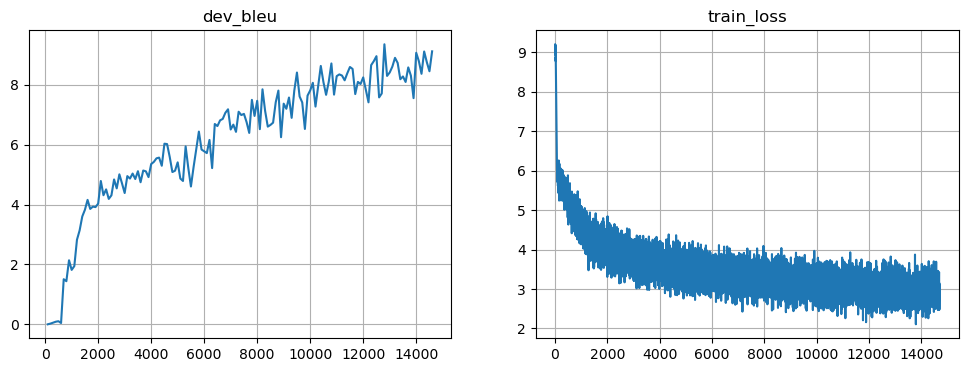

Mean loss=2.879


In [75]:
print_results(attentive_model_lstm)
plot_loss_bleu(attentive_model_lstm.train_losses, attentive_model_lstm.dev_bleus)

In [76]:
attentive_model_gru = AttentiveModel_GRU(inp_voc, out_voc)
train_model(attentive_model_gru, train_dataloader, val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | emb_inp   | Embedding      | 502 K  | train
1 | emb_out   | Embedding      | 473 K  | train
2 | enc0      | GRU            | 12.7 K | train
3 | dec_start | Linear         | 1.1 K  | train
4 | dec0      | GRUCell        | 9.4 K  | train
5 | logits    | Linear         | 488 K  | train
6 | attention | AttentionLayer | 2.1 K  | train
-----------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
5.963     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

Metric dev_bleu improved. New best score: 2.364
Metric dev_bleu improved by 2.410 >= min_delta = 0.0. New best score: 4.774
Metric dev_bleu improved by 0.988 >= min_delta = 0.0. New best score: 5.761
Metric dev_bleu improved by 0.630 >= min_delta = 0.0. New best score: 6.391
Metric dev_bleu improved by 0.608 >= min_delta = 0.0. New best score: 6.999
Metric dev_bleu improved by 0.519 >= min_delta = 0.0. New best score: 7.517
Metric dev_bleu improved by 0.440 >= min_delta = 0.0. New best score: 7.957
Metric dev_bleu improved by 0.484 >= min_delta = 0.0. New best score: 8.441
Metric dev_bleu improved by 0.170 >= min_delta = 0.0. New best score: 8.611
Metric dev_bleu improved by 0.246 >= min_delta = 0.0. New best score: 8.857
`Trainer.fit` stopped: `max_epochs=10` reached.


BLEU: 9.724526630555724
всем гостям предоставляются японские халаты юката . на территории предусмотрена бесплатная парковка .
guests can also use a shared lounge with free parking .

в просторном саду апартаментов sch@@ ne@@ it@@ erhof есть детская игровая площадка , принадлежности для барбекю и садовая мебель .
the hotel also has a garden , a garden and a terrace with a terrace and a drink in the garden .

поездка до торгового центра dolce vita fun@@ ch@@ al с магазинами , кинотеат@@ рами и ресторан@@ ными двори@@ ками займет 13 минут .
the hotel is located in the centre of the centre of the surroundings , and the famous world heritage is a 5-minute drive away .

гостям апартаментов предоставляется бесплатный wifi .
free wifi access is available .

в распоряжении гостей номера с общей ванной комнатой .
the rooms are equipped with a private bathroom .

поездка на автомобиле до торгового центра ten@@ ero займет 3 минуты , на территории гостевого дома предоставляется бесплатная частная п

<Figure size 640x480 with 0 Axes>

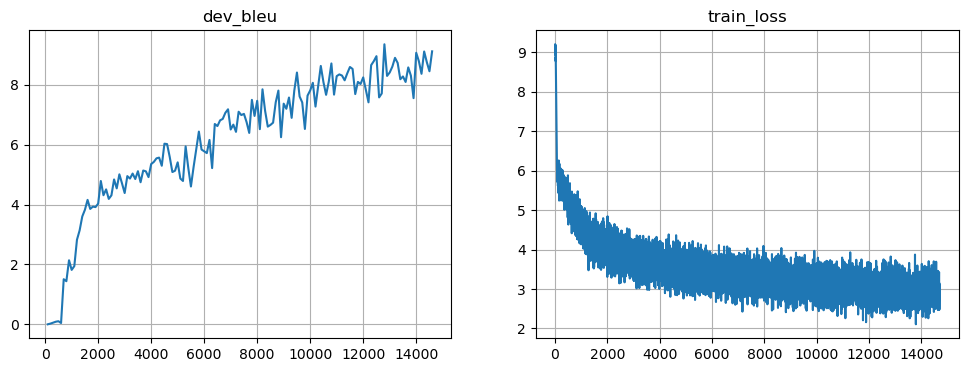

Mean loss=2.879


In [77]:
print_results(attentive_model_gru)
plot_loss_bleu(attentive_model_lstm.train_losses, attentive_model_lstm.dev_bleus)

In [78]:
attentive_model_bidrect = AttentiveModel_Bidirectional(inp_voc, out_voc)
train_model(attentive_model_bidrect, train_dataloader, val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | emb_inp   | Embedding      | 502 K  | train
1 | emb_out   | Embedding      | 473 K  | train
2 | enc0      | LSTM           | 42.0 K | train
3 | dec_start | Linear         | 1.1 K  | train
4 | dec0      | GRUCell        | 9.4 K  | train
5 | logits    | Linear         | 488 K  | train
6 | attn_proj | Linear         | 2.1 K  | train
7 | attention | AttentionLayer | 3.2 K  | train
-----------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
6.093     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

Metric dev_bleu improved. New best score: 1.612
Metric dev_bleu improved by 2.706 >= min_delta = 0.0. New best score: 4.318
Metric dev_bleu improved by 1.919 >= min_delta = 0.0. New best score: 6.237
Metric dev_bleu improved by 1.039 >= min_delta = 0.0. New best score: 7.276
Metric dev_bleu improved by 1.085 >= min_delta = 0.0. New best score: 8.361
Metric dev_bleu improved by 0.365 >= min_delta = 0.0. New best score: 8.727
Metric dev_bleu improved by 0.286 >= min_delta = 0.0. New best score: 9.012
Metric dev_bleu improved by 0.371 >= min_delta = 0.0. New best score: 9.383
Metric dev_bleu improved by 0.105 >= min_delta = 0.0. New best score: 9.488
`Trainer.fit` stopped: `max_epochs=10` reached.


BLEU: 8.873953913117179
всем гостям предоставляются японские халаты юката . на территории предусмотрена бесплатная парковка .
the property offers free parking , and a laundry .

в просторном саду апартаментов sch@@ ne@@ it@@ erhof есть детская игровая площадка , принадлежности для барбекю и садовая мебель .
at casa de la maison garden you will find a garden and a terrace .

поездка до торгового центра dolce vita fun@@ ch@@ al с магазинами , кинотеат@@ рами и ресторан@@ ными двори@@ ками займет 13 минут .
the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the hotel and the hotel .

гостям апартаментов предоставляется бесплатный wifi .
free wifi is available .

в распоряжении гостей номера с общей ванной комнатой .
rooms are equipped with a private bathroom .

поездка на автомобиле до торгового центра ten@@ ero займет 3 минуты , на территории гостевого дома предоставляется бесплатная ча

<Figure size 640x480 with 0 Axes>

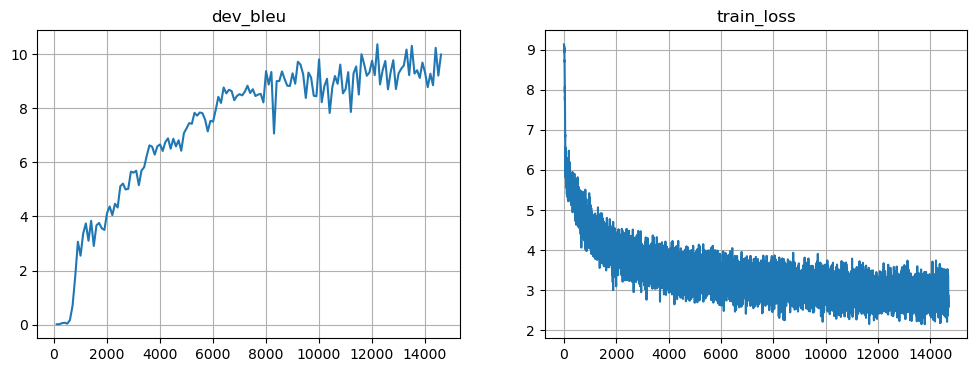

Mean loss=2.866


In [79]:
print_results(attentive_model_bidrect)
plot_loss_bleu(attentive_model_bidrect.train_losses, attentive_model_bidrect.dev_bleus)

### Вывод

Учет контекста с обеих сторон (`bidirectional`) может положительно повлиять на результат, но понизить производительность.

### Этап 4 -  `lr sheduling`, `early stopping`, эксперименты с оптимизатором

In [80]:
configs = [
    {ConfigKeys.OPTIMIZER.value: torch.optim.AdamW},
    {ConfigKeys.OPTIMIZER.value: torch.optim.Adagrad},
    {ConfigKeys.SCHEDULER.value: True},
    {ConfigKeys.OPTIMIZER.value: torch.optim.AdamW,
     ConfigKeys.SCHEDULER.value: True},
    {ConfigKeys.OPTIMIZER.value: torch.optim.AdamW,
     ConfigKeys.SCHEDULER.value: True,
     ConfigKeys.NUM_LAYERS.value: 3},
]


In [81]:
attentive_lstm_adamw = AttentiveModel(inp_voc, out_voc, config=configs[0]).to(device)
train_model(attentive_lstm_adamw, train_dataloader, val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | emb_inp   | Embedding      | 502 K  | train
1 | emb_out   | Embedding      | 473 K  | train
2 | enc0      | LSTM           | 16.9 K | train
3 | dec_start | Linear         | 1.1 K  | train
4 | dec0      | GRUCell        | 9.4 K  | train
5 | logits    | Linear         | 488 K  | train
6 | attention | AttentionLayer | 2.1 K  | train
-----------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
5.980     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

Metric dev_bleu improved. New best score: 1.852
Metric dev_bleu improved by 2.062 >= min_delta = 0.0. New best score: 3.914
Metric dev_bleu improved by 0.969 >= min_delta = 0.0. New best score: 4.882
Metric dev_bleu improved by 1.015 >= min_delta = 0.0. New best score: 5.898
Metric dev_bleu improved by 0.985 >= min_delta = 0.0. New best score: 6.883
Metric dev_bleu improved by 0.815 >= min_delta = 0.0. New best score: 7.697
Metric dev_bleu improved by 0.532 >= min_delta = 0.0. New best score: 8.229
Metric dev_bleu improved by 0.475 >= min_delta = 0.0. New best score: 8.704
Metric dev_bleu improved by 0.365 >= min_delta = 0.0. New best score: 9.070
Metric dev_bleu improved by 0.340 >= min_delta = 0.0. New best score: 9.410
`Trainer.fit` stopped: `max_epochs=10` reached.


BLEU: 9.82677317998816
всем гостям предоставляются японские халаты юката . на территории предусмотрена бесплатная парковка .
free private parking is available on site .

в просторном саду апартаментов sch@@ ne@@ it@@ erhof есть детская игровая площадка , принадлежности для барбекю и садовая мебель .
it offers a terrace and a terrace and a terrace with a terrace and a terrace .

поездка до торгового центра dolce vita fun@@ ch@@ al с магазинами , кинотеат@@ рами и ресторан@@ ными двори@@ ками займет 13 минут .
the hotel is a 15-minute drive from the hotel , and a restaurant and a restaurant and a variety of the local and international airport .

гостям апартаментов предоставляется бесплатный wifi .
free wifi is available .

в распоряжении гостей номера с общей ванной комнатой .
the rooms are equipped with a tv .

поездка на автомобиле до торгового центра ten@@ ero займет 3 минуты , на территории гостевого дома предоставляется бесплатная частная парковка .
free parking is available in the

<Figure size 640x480 with 0 Axes>

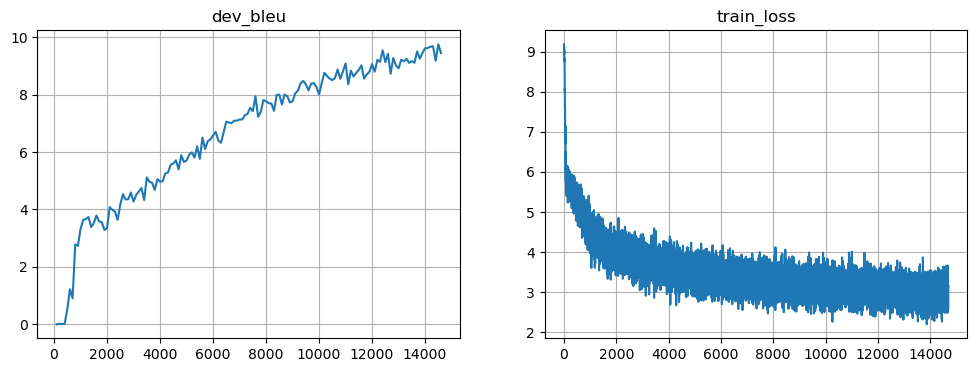

Mean loss=2.997


In [82]:
print_results(attentive_lstm_adamw)
plot_loss_bleu(attentive_lstm_adamw.train_losses, attentive_lstm_adamw.dev_bleus)

In [83]:
attentive_lstm_adagrad = AttentiveModel(inp_voc, out_voc, config=configs[1]).to(device)
train_model(attentive_lstm_adagrad, train_dataloader, val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | emb_inp   | Embedding      | 502 K  | train
1 | emb_out   | Embedding      | 473 K  | train
2 | enc0      | LSTM           | 16.9 K | train
3 | dec_start | Linear         | 1.1 K  | train
4 | dec0      | GRUCell        | 9.4 K  | train
5 | logits    | Linear         | 488 K  | train
6 | attention | AttentionLayer | 2.1 K  | train
-----------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
5.980     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

Metric dev_bleu improved. New best score: 0.001
Metric dev_bleu improved by 0.010 >= min_delta = 0.0. New best score: 0.010
Metric dev_bleu improved by 0.014 >= min_delta = 0.0. New best score: 0.024
Metric dev_bleu improved by 0.029 >= min_delta = 0.0. New best score: 0.053
Metric dev_bleu improved by 0.001 >= min_delta = 0.0. New best score: 0.055
Monitored metric dev_bleu did not improve in the last 3 records. Best score: 0.055. Signaling Trainer to stop.


BLEU: 0.04667486724768117
всем гостям предоставляются японские халаты юката . на территории предусмотрена бесплатная парковка .
the is a a .

в просторном саду апартаментов sch@@ ne@@ it@@ erhof есть детская игровая площадка , принадлежности для барбекю и садовая мебель .
the is a a a .

поездка до торгового центра dolce vita fun@@ ch@@ al с магазинами , кинотеат@@ рами и ресторан@@ ными двори@@ ками займет 13 минут .
the is a a a .

гостям апартаментов предоставляется бесплатный wifi .
the is a a .

в распоряжении гостей номера с общей ванной комнатой .
the is a a .

поездка на автомобиле до торгового центра ten@@ ero займет 3 минуты , на территории гостевого дома предоставляется бесплатная частная парковка .
the is a a a .



<Figure size 640x480 with 0 Axes>

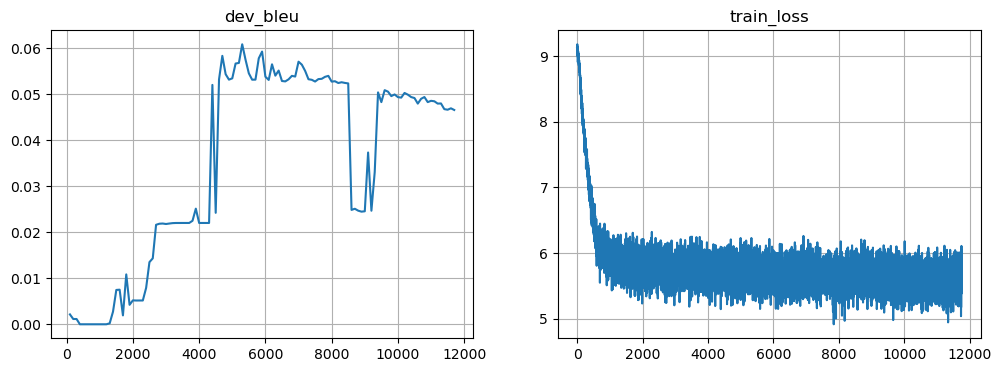

Mean loss=5.628


In [84]:
print_results(attentive_lstm_adagrad)
plot_loss_bleu(attentive_lstm_adagrad.train_losses, attentive_lstm_adagrad.dev_bleus)

In [85]:
attentive_lstm_scheduler = AttentiveModel(inp_voc, out_voc, config=configs[2]).to(device)
train_model(attentive_lstm_scheduler, train_dataloader, val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | emb_inp   | Embedding      | 502 K  | train
1 | emb_out   | Embedding      | 473 K  | train
2 | enc0      | LSTM           | 16.9 K | train
3 | dec_start | Linear         | 1.1 K  | train
4 | dec0      | GRUCell        | 9.4 K  | train
5 | logits    | Linear         | 488 K  | train
6 | attention | AttentionLayer | 2.1 K  | train
-----------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
5.980     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

Metric dev_bleu improved. New best score: 1.244
Metric dev_bleu improved by 2.728 >= min_delta = 0.0. New best score: 3.972
Metric dev_bleu improved by 1.214 >= min_delta = 0.0. New best score: 5.186
Metric dev_bleu improved by 1.183 >= min_delta = 0.0. New best score: 6.369
Metric dev_bleu improved by 0.657 >= min_delta = 0.0. New best score: 7.025
Metric dev_bleu improved by 0.478 >= min_delta = 0.0. New best score: 7.503
Metric dev_bleu improved by 0.478 >= min_delta = 0.0. New best score: 7.981
Metric dev_bleu improved by 0.337 >= min_delta = 0.0. New best score: 8.318
Metric dev_bleu improved by 0.258 >= min_delta = 0.0. New best score: 8.576
Metric dev_bleu improved by 0.352 >= min_delta = 0.0. New best score: 8.928
`Trainer.fit` stopped: `max_epochs=10` reached.


BLEU: 8.961453742386237
всем гостям предоставляются японские халаты юката . на территории предусмотрена бесплатная парковка .
free parking is available at the property .

в просторном саду апартаментов sch@@ ne@@ it@@ erhof есть детская игровая площадка , принадлежности для барбекю и садовая мебель .
the hotel offers a garden with a terrace with barbecue facilities , a barbecue facilities .

поездка до торгового центра dolce vita fun@@ ch@@ al с магазинами , кинотеат@@ рами и ресторан@@ ными двори@@ ками займет 13 минут .
the hotel is a 10-minute drive from the hotel ’ s centre of the centre of the hotel .

гостям апартаментов предоставляется бесплатный wifi .
free wifi is available .

в распоряжении гостей номера с общей ванной комнатой .
the rooms have a private bathroom .

поездка на автомобиле до торгового центра ten@@ ero займет 3 минуты , на территории гостевого дома предоставляется бесплатная частная парковка .
the hotel is a 40-minute drive from the hotel , and the private park

<Figure size 640x480 with 0 Axes>

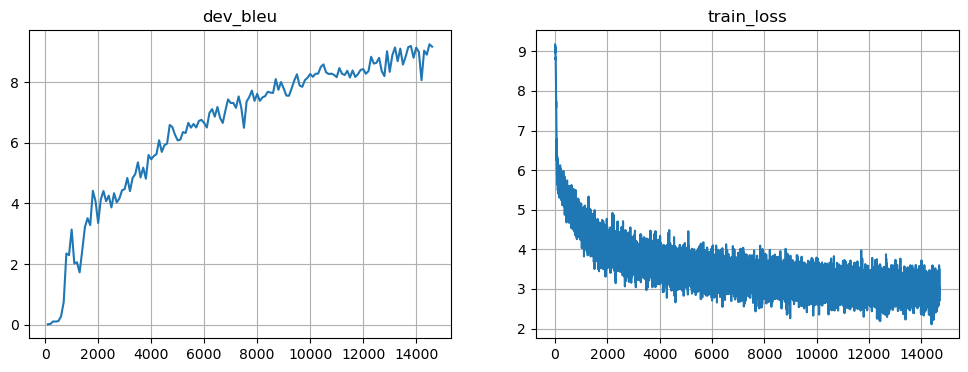

Mean loss=2.982


In [86]:
print_results(attentive_lstm_scheduler)
plot_loss_bleu(attentive_lstm_scheduler.train_losses, attentive_lstm_scheduler.dev_bleus)

In [87]:
attentive_lstm_adamw_scheduler = AttentiveModel(inp_voc, out_voc, config=configs[3]).to(device)
train_model(attentive_lstm_adamw_scheduler, train_dataloader, val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | emb_inp   | Embedding      | 502 K  | train
1 | emb_out   | Embedding      | 473 K  | train
2 | enc0      | LSTM           | 16.9 K | train
3 | dec_start | Linear         | 1.1 K  | train
4 | dec0      | GRUCell        | 9.4 K  | train
5 | logits    | Linear         | 488 K  | train
6 | attention | AttentionLayer | 2.1 K  | train
-----------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
5.980     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

Metric dev_bleu improved. New best score: 1.286
Metric dev_bleu improved by 2.828 >= min_delta = 0.0. New best score: 4.114
Metric dev_bleu improved by 1.400 >= min_delta = 0.0. New best score: 5.514
Metric dev_bleu improved by 0.708 >= min_delta = 0.0. New best score: 6.221
Metric dev_bleu improved by 0.700 >= min_delta = 0.0. New best score: 6.921
Metric dev_bleu improved by 0.970 >= min_delta = 0.0. New best score: 7.892
Metric dev_bleu improved by 0.500 >= min_delta = 0.0. New best score: 8.392
Metric dev_bleu improved by 0.559 >= min_delta = 0.0. New best score: 8.950
Metric dev_bleu improved by 0.229 >= min_delta = 0.0. New best score: 9.179
Metric dev_bleu improved by 0.300 >= min_delta = 0.0. New best score: 9.479
`Trainer.fit` stopped: `max_epochs=10` reached.


BLEU: 9.754992099062955
всем гостям предоставляются японские халаты юката . на территории предусмотрена бесплатная парковка .
free wifi is available throughout the property .

в просторном саду апартаментов sch@@ ne@@ it@@ erhof есть детская игровая площадка , принадлежности для барбекю и садовая мебель .
the hotel features a garden with a garden and a terrace with a garden .

поездка до торгового центра dolce vita fun@@ ch@@ al с магазинами , кинотеат@@ рами и ресторан@@ ными двори@@ ками займет 13 минут .
the hotel ’ s hotel is a 5-minute walk from the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre of the centre .

гостям апартаментов предоставляется бесплатный wifi .
free wifi is available .

в распоряжении гостей номера с общей ванной комнатой .
the rooms are fitted with a 

<Figure size 640x480 with 0 Axes>

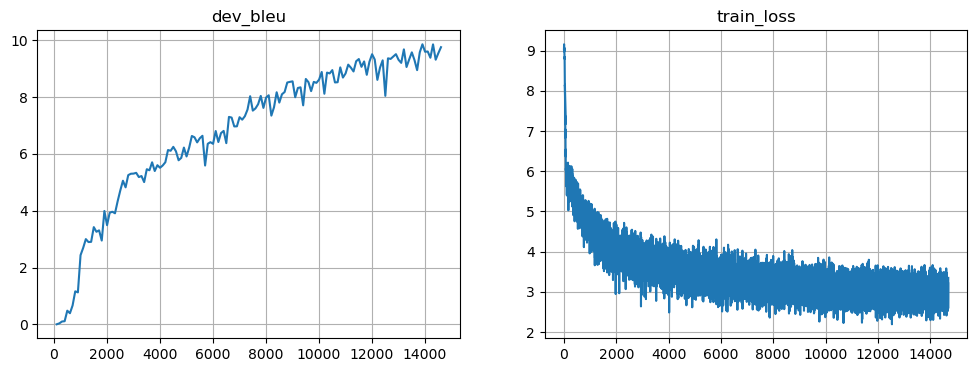

Mean loss=3.006


In [88]:
print_results(attentive_lstm_adamw_scheduler)
plot_loss_bleu(attentive_lstm_adamw_scheduler.train_losses, attentive_lstm_adamw_scheduler.dev_bleus)

### Вывод

GRU сработал лучше, чем LSTM (на этих данных).
Учет контекста с обеих сторон (`bidirectional`) может положительно повлиять на результат, но понизить производительность.

### Лучшая модель

In [89]:
attentive_gru_adamw_scheduler = AttentiveModel_GRU(inp_voc, out_voc, config=configs[4]).to(device)
train_model(attentive_gru_adamw_scheduler, train_dataloader, val_dataloader, max_epochs=25)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | emb_inp   | Embedding      | 502 K  | train
1 | emb_out   | Embedding      | 473 K  | train
2 | enc0      | GRU            | 19.0 K | train
3 | dec_start | Linear         | 1.1 K  | train
4 | dec0      | GRUCell        | 9.4 K  | train
5 | logits    | Linear         | 488 K  | train
6 | attention | AttentionLayer | 2.1 K  | train
-----------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
5.989     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

Metric dev_bleu improved. New best score: 1.349
Metric dev_bleu improved by 2.178 >= min_delta = 0.0. New best score: 3.526
Metric dev_bleu improved by 1.221 >= min_delta = 0.0. New best score: 4.747
Metric dev_bleu improved by 0.087 >= min_delta = 0.0. New best score: 4.833
Metric dev_bleu improved by 0.393 >= min_delta = 0.0. New best score: 5.227
Metric dev_bleu improved by 0.694 >= min_delta = 0.0. New best score: 5.920
Metric dev_bleu improved by 0.545 >= min_delta = 0.0. New best score: 6.465
Metric dev_bleu improved by 0.056 >= min_delta = 0.0. New best score: 6.521
Metric dev_bleu improved by 1.009 >= min_delta = 0.0. New best score: 7.530
Metric dev_bleu improved by 0.163 >= min_delta = 0.0. New best score: 7.693
Metric dev_bleu improved by 0.485 >= min_delta = 0.0. New best score: 8.178
Metric dev_bleu improved by 0.543 >= min_delta = 0.0. New best score: 8.721
Metric dev_bleu improved by 0.076 >= min_delta = 0.0. New best score: 8.797
Metric dev_bleu improved by 0.300 >= min

BLEU: 9.983541024906817
всем гостям предоставляются японские халаты юката . на территории предусмотрена бесплатная парковка .
the property offers a 24-hour front desk and free private parking is available on site .

в просторном саду апартаментов sch@@ ne@@ it@@ erhof есть детская игровая площадка , принадлежности для барбекю и садовая мебель .
the property offers a barbecue and barbecue facilities , barbecue facilities .

поездка до торгового центра dolce vita fun@@ ch@@ al с магазинами , кинотеат@@ рами и ресторан@@ ными двори@@ ками займет 13 минут .
the property is a 10-minute walk from the property , while the property is a 10-minute walk away .

гостям апартаментов предоставляется бесплатный wifi .
free wifi access is available .

в распоряжении гостей номера с общей ванной комнатой .
the rooms have a shared bathroom .

поездка на автомобиле до торгового центра ten@@ ero займет 3 минуты , на территории гостевого дома предоставляется бесплатная частная парковка .
the property is a

<Figure size 640x480 with 0 Axes>

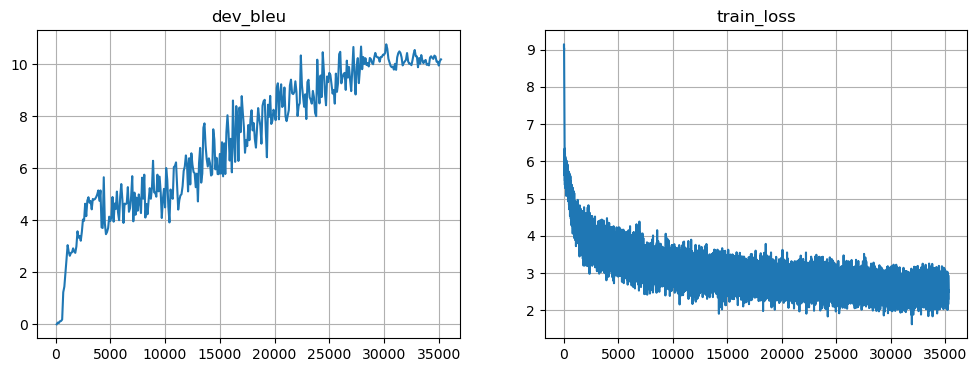

Mean loss=2.563


In [90]:
print_results(attentive_gru_adamw_scheduler)
plot_loss_bleu(attentive_gru_adamw_scheduler.train_losses, attentive_gru_adamw_scheduler.dev_bleus)

## Этап 5 - Эксперименты с inference



### Используем не только `greedy`, но и `sampling` метод

In [111]:
sample_inputs = dev_inp[:5]
print(*sample_inputs)

всем гостям предоставляются японские халаты юката . на территории предусмотрена бесплатная парковка . апартаменты casa della g@@ hi@@ anda@@ ia расположены в 5 минутах ходьбы от ближайшего песчаного пляжа в порто-@@ чезаре@@ о . к услугам гостей апартаменты с кондиционером и телевизором с плоским экраном . в каждом номере отеля cand@@ i@@ ani имеется кондиционер , мини-бар и телевизор со спутниковыми каналами . поездка до ресторана lang@@ dal@@ es viney@@ ard занимает 20 минут . в лобби-баре некоторые местные алкогольные и безалкогольные напитки подаются бесплатно .


In [117]:
greedy_translations, _ = attentive_gru_adamw_scheduler.translate_lines(sample_inputs, method="greedy", max_len=25)
print("Greedy decoding results:\n")
for t in greedy_translations:
    print(t)

Greedy decoding results:

the property offers a 24-hour front desk and free private parking is available on site .
located in the heart of rome , this hotel is a 10-minute walk from the city of the city centre .
each room at the hotel is air conditioned and feature a tv , air conditioning and a minibar .
the hotel ’ s staff can be reached by a tour desk .
drinks and drinks are available in the lobby .


In [116]:
sampling_translations, _ = attentive_gru_adamw_scheduler.translate_lines(sample_inputs, method="sampling", max_len=25, top_k=10, temperature=0.7)
print("Sampling decoding results:\n")
for t in sampling_translations:
    print(t)

Sampling decoding results:

extras include fax and cleaning services .
located 200 metres from the main square of the hotel is located in rome ’ walk from the beach , 3 minutes ’ walk from
all rooms at the air-conditioned rooms at this hotel are decorated with air conditioning and safe , minibar and a minibar .
the hotel ' s place also offers a 15-minute drive from the guest house .
a drinks drinks and snacks are available .


### Вывод

Очевидно, качество перевода оставляет желать лучшего.

Но также видно, что метод `sampling` значительно разнообразил тексты, хотя и качество умозрительно кажется ниже, чем с `greedy`

## Этап 6 - Финальные выводы

1. **Размер словаря:**
Увеличение размера словаря снижает среднюю длину последовательности (с 17.72 токенов при 8192 до 16.70 при 32768), что положительно сказывается на вычислительной сложности. При этом прирост снижения длины от 16 до 32 тысяч минимален, а размер словаря значительно растёт. Оптимальным выглядит около 16 тысяч.

2. **Архитектура модели:**
GRU сработал лучше, чем LSTM на этих данных.
Учет контекста с обеих сторон (`bidirectional`) может положительно повлиять на результат, но понизить производительность.

3. **Оптимизация обучения:**
С `early stopping` можно остановить обучение, при отсутствии улучшения целевой метрики. C `lr sheduling` модели могут быстрее достичь оптимальных значений, также могут избегать застревания в локальных минимумах. На вычисления планировщика уходит время, но его работа может ускорить сходимость.

4. **Методы инференса:**
Метод `sampling` обеспечивает разнообразие переводов, однако по умозрительной оценке их качество уступает `greedy` версии. Возможно, были выбраны не лучшие параметры для `sampling`.

В итоге, мы видим, что результаты работы на занятии можно улучшить с помощью описанных шагов, что и было сделано.

> P.S: Изменил значения  `emb_size`, `hid_size`, `attn_size` , т.к. мне не хватило графической памяти. В `Colab` в конфигурации 64/128/128 (соответственно) из-за выхода за лимит по времени. Проверял в `Colab` (конфигурация 64/128/128) : удалось добиться лучших результатов чем исходная модель (AttentiveModel) на паре